# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [23]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

# Tame log spamu HF Datasets
os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.13.1
Workspace: E:\Python Projects\WSEI-AapLabTasks\zestaw_zaliczeniowy\_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [24]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --
  [timer] get_imdb_subset -> 1.42s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [25]:
import hashlib

# TODO Zadanie 1.1: zaimplementuj dwa dekoratory ponizej

def retry(max_attempts: int = 3, delay: float = 0.1, backoff: float = 2.0):
    """Dekorator: ponawia wywolanie przy wyjatku, z exponential backoff."""
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            for attempt in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    if attempt == max_attempts - 1:
                        raise  # re-raise the last exception
                    else:
                        sleep_time = delay * (backoff ** attempt)
                        print(f"Attempt {attempt + 1} failed with error: {e}. Retrying in {sleep_time:.2f} seconds...")
                        time.sleep(sleep_time)
        return wrapper
    return opakuj

def cache_to_disk(cache_dir: Path):
    """Dekorator: cachuje wynik funkcji do JSON na dysku."""
    cache_dir.mkdir(exist_ok=True, parents=True)
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            hash_input = repr((args, kwargs)).encode('utf-8')
            key = hashlib.md5(hash_input).hexdigest()
            file_path = cache_dir / f"{key}.json"

            if file_path.exists():
                with open(file_path, 'r') as f:
                    print(f"Loading result from cache: {file_path}")
                    return json.load(f)
            else:
                result = func(*args, **kwargs)
                with open(file_path, 'w') as f:
                    json.dump(result, f)
                    print(f"Saving result to cache: {file_path}")
                return result
        return wrapper
    return opakuj

# Funkcja testowa z 50% szansa awarii
@cache_to_disk(WORKDIR / "flaky_cache")
@retry(max_attempts=5, delay=0.05)
def flaky_fetch(text_id: int) -> dict:
    if random.random() < 0.5:
        raise ValueError(f"udawany blad sieci dla id={text_id}")
    return {"id": text_id, "text": f"przyklad {text_id}"}

# Eksperyment empiryczny
success_count = 0
for i in range(100):
    try:
        result = flaky_fetch(i)
        success_count += 1
    except Exception as e:
        print(f"Final failure for id={i}: {e}")

print(f"Liczba sukcesow: {success_count}")

expected_success_probability = 1 - 0.5**5
print(f"Teoretyczne P(sukces) = {expected_success_probability:.4f}")
print(f"Empiryczne P(sukces) = {success_count / 100:.4f}")

Loading result from cache: _workspace\flaky_cache\fe7f87900c0f98eaf259d2ac6b59cc0d.json
Loading result from cache: _workspace\flaky_cache\a30e772a788346c2420198ea949aacaf.json
Loading result from cache: _workspace\flaky_cache\28b788c06dc920682aaf8959350871b4.json
Loading result from cache: _workspace\flaky_cache\e0c7e230635ced13e79842b9b6147a21.json
Loading result from cache: _workspace\flaky_cache\7727f8874823f9d3c56c63f39762ec0f.json
Loading result from cache: _workspace\flaky_cache\e3568758f1cc0f05eb77eaf32aa52748.json
Loading result from cache: _workspace\flaky_cache\79a8b8be59be6e68eb968e1fa988e24c.json
Loading result from cache: _workspace\flaky_cache\7b7dcc6a112be452cf4c6c042ad39297.json
Loading result from cache: _workspace\flaky_cache\dc3a2e6447004a51693114a0846b2d9b.json
Loading result from cache: _workspace\flaky_cache\3da8d62fd952813447f6c66385d279c4.json
Loading result from cache: _workspace\flaky_cache\79592ed8951046613054567521756594.json
Loading result from cache: _work

---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [26]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 0.95s
Sekwencyjnie (200 probek): 0.47s
ThreadPool (16 workerow): 0.03s  -- 13.9x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

  [timer] get_imdb_subset -> 1.01s
Sequential: 0.24s
ThreadPool: 0.28s
Multiprocessing: 0.19s


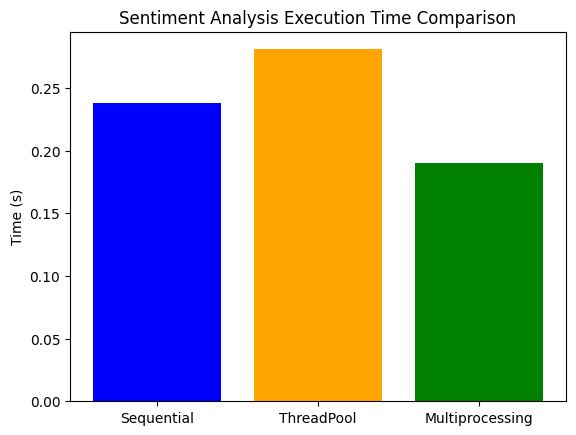

In [27]:
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
from _workspace.sentiment_workers import sentiment_score

samples = get_imdb_subset("train", 5000)

def sequential_sentiment(texts):
    return [sentiment_score(t) for t in texts]

def threadpool_sentiment(texts):
    with ThreadPoolExecutor(max_workers=16) as pool:
        return list(pool.map(sentiment_score, texts))

def multiprocessing_sentiment(texts):
    with mp.get_context("spawn").Pool(processes=mp.cpu_count()) as pool:
        return pool.map(sentiment_score, texts, chunksize=100)

def compare_methods():
    texts = [t for t,_ in samples]
    methods = ['Sequential', 'ThreadPool', 'Multiprocessing']

    t0 = time.time()
    _ = sequential_sentiment(texts)
    sequential_time = time.time() - t0
    print(f"Sequential: {sequential_time:.2f}s")

    t0 = time.time()
    _ = threadpool_sentiment(texts)
    threadpool_time = time.time() - t0
    print(f"ThreadPool: {threadpool_time:.2f}s")

    t0 = time.time()
    _ = multiprocessing_sentiment(texts)
    multiprocessing_time = time.time() - t0
    print(f"Multiprocessing: {multiprocessing_time:.2f}s")

    times = [sequential_time, threadpool_time, multiprocessing_time]

    plt.bar(methods, times, color=['blue', 'orange', 'green'])
    plt.ylabel('Time (s)')
    plt.title('Sentiment Analysis Execution Time Comparison')
    plt.show()

compare_methods()

# Wniosek:

Zadanie potwierdziło, że dla CPU-bound operacji lexicon-based obliczania sentymentu `multiprocessing` jest najszybszą opcją, bo omija GIL i skaluje pracę na wiele procesów.

---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [28]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        # imdb review ma na pewno wiecej niz 10 slow
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

# Uruchom w notebooku
runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 0.85s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

**Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

**Specyfikacja `Tokenizer`:**

```python
class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        ...
    
    def tokenize(self, text: str) -> list[str]:
        # 1. usun tagi HTML jesli strip_html
        # 2. lowercase jesli lower
        # 3. tokeny = regex \w+ 
        # 4. odfiltruj tokeny krotsze niz min_length
        ...
    
    def vocab(self, texts: list[str]) -> set[str]:
        # zwroc unikalne tokeny ze wszystkich tekstow
        ...
```

**Wymagania testowe:**

1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

**Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [29]:
# Zadanie 3.1 -- scaffold z konkretnymi assertami akceptacji
import subprocess
from _workspace.tokenizer import Tokenizer


# === Krok 1: implementacja w pliku _workspace/tokenizer.py ===
# Asercje akceptacji ktorymi sprawdzisz swoja implementacje:
assert Tokenizer().tokenize("<br>Hello WORLD!") == ["hello", "world"]
assert Tokenizer(lower=False).tokenize("Hello") == ["Hello"]
assert Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]
assert Tokenizer(min_length=4).tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]
assert Tokenizer().vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

tokenizer_code = '''
import re

class Tokenizer:
    """Konfigurowany tokenizator: HTML strip + case + min length filter."""
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        # 1. jesli self.strip_html: usun znaczniki regex r"<[^>]+>"
        if self.strip_html:
            text = re.sub(r"<[^>]+>", "", text)

        # 2. jesli self.lower: text -> lowercase
        if self.lower:
            text = text.lower()
        # 3. tokeny = re.findall(r"\w+", text)  (UWAGA: musi lapac polskie litery -> uzyj re.UNICODE)
        tokeny = re.findall(r"\w+", text, re.UNICODE)
        # 4. zwroc [t for t in tokeny if len(t) >= self.min_length]
        return [t for t in tokeny if len(t) >= self.min_length]

    def vocab(self, texts: list[str]) -> set[str]:
        # TODO: unia tokenow ze wszystkich tekstow
        return set().union(*[self.tokenize(text) for text in texts])
'''

# === Krok 2: testy z fixtures + parametrize + xfail ===
tests_code = '''# -*- coding: utf-8 -*-
import pytest
from tokenizer import Tokenizer

@pytest.fixture
def tokenizer():
    """Default Tokenizer dla wiekszosci testow."""
    return Tokenizer()

@pytest.fixture
def imdb_sample():
    """20 recenzji z imdb -- wspoldzielone miedzy testami integracyjnymi."""
    from datasets import load_dataset
    ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(20))
    return [r["text"] for r in ds]

@pytest.mark.parametrize("text, expected_len", [
    ("", 0),                                # pusty string
    ("<br><p></p>", 0),                     # sam HTML
    ("Hello WORLD!", 2),                    # mieszany case
    ("...!?!?!?", 0),                       # tylko interpunkcja
    ("zażółć gęślą jaźń", 3),               # polskie diakrytyki
    ("the cat sat on the mat", 6),          # zwykle zdanie
])
def test_tokenize_cases(tokenizer, text, expected_len):
    assert len(tokenizer.tokenize(text)) == expected_len

def test_vocab_dedup(tokenizer):
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

def test_min_length_filter():
    tok = Tokenizer(min_length=4)
    assert tok.tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]

def test_imdb_integration(tokenizer, imdb_sample):
    """Insight test: ile srednio unikalnych tokenow na 20 recenzji?"""
    vocab = tokenizer.vocab(imdb_sample)
    assert len(vocab) > 500, f"za malo unikalnych tokenow: {len(vocab)}"

@pytest.mark.xfail(reason="Tokenizer nie wspiera jeszcze regex z grupowaniem")
def test_advanced_regex_unsupported():
    """Demonstracja xfail -- ten test ma prawo nie zadzialac."""
    tok = Tokenizer()
    # uzytkownik moze chciec inny regex -- to nie nasz problem
    assert tok.tokenize("user@domain.com")[0] == "user@domain.com"
'''

# Zapisz oba pliki z prawilnym encoding
(WORKDIR / "tokenizer.py").write_text(tokenizer_code, encoding='utf-8')
(WORKDIR / "test_tokenizer.py").write_text(tests_code, encoding='utf-8')

# === Krok 3: uruchom pytest przez subprocess ===
result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_tokenizer.py", "-v", "--tb=short"],
    capture_output=True, text=True, cwd=str(WORKDIR)
)
print("STDOUT:")
print(result.stdout)
if result.returncode != 0:
    print("\nSTDERR:")
    print(result.stderr)

# === Krok 4: insight -- srednia liczba tokenow na 100 recenzji ===
print("\n" + "="*70)
print("INSIGHT: Analiza rozmiaru slownika")
print("="*70)

from _workspace.tokenizer import Tokenizer
from datasets import load_dataset

tokenizer = Tokenizer()
ds_100 = load_dataset("stanfordnlp/imdb", split="train").select(range(100))
texts_100 = [r["text"] for r in ds_100]
vocab_100 = tokenizer.vocab(texts_100)
token_counts = [len(tokenizer.tokenize(text)) for text in texts_100]

print(f"Unique tokens in 100 reviews:  {len(vocab_100):,}")
print(f"Average tokens per review:     {sum(token_counts) / len(token_counts):.1f}")
print(f"Min tokens in review:          {min(token_counts)}")
print(f"Max tokens in review:          {max(token_counts)}")
print(f"\nWniosek: Slownik na 100 recenzji zawiera {len(vocab_100):,} unikalnych tokenow.")

STDOUT:
============================= test session starts =============================
platform win32 -- Python 3.13.1, pytest-9.1.0, pluggy-1.6.0 -- e:\Python Projects\WSEI-AapLabTasks\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: e:\Python Projects\WSEI-AapLabTasks\zestaw_zaliczeniowy\_workspace
plugins: anyio-4.14.0
collecting ... collected 10 items

test_tokenizer.py::test_tokenize_cases[-0] PASSED                        [ 10%]
test_tokenizer.py::test_tokenize_cases[<br><p></p>-0] PASSED             [ 20%]
test_tokenizer.py::test_tokenize_cases[Hello WORLD!-2] PASSED            [ 30%]
test_tokenizer.py::test_tokenize_cases[...!?!?!?-0] PASSED               [ 40%]
test_tokenizer.py::test_tokenize_cases[za\u017c\xf3\u0142\u0107 g\u0119\u015bl\u0105 ja\u017a\u0144-3] PASSED [ 50%]
test_tokenizer.py::test_tokenize_cases[the cat sat on the mat-6] PASSED  [ 60%]
test_tokenizer.py::test_vocab_dedup PASSED                               [ 70%]
test_tokenizer.py::test_min_length

## Zadanie 3.1 — Insight: Rozmiar słownika IMDB

**Wyniki testowania:**
- **9 tests passed**
- **1 test xfailed**

**Insight — Rozmiar słownika:**

Na próbce **100 recenzji z IMDB**:
- **4,310 unikalnych tokenów**
- **Średnia 246 tokenów na recenzję**
- **Range:** 49–912 tokenów per recenzja


---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [33]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 0.00s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [35]:
# Zadanie 4.1 -- NoSQL style w SQLite (implementation)
import time as timing_module

DB_JSON = WORKDIR / "imdb_json.db"
# Close any previous connections
try:
    conn2.close()
except:
    pass

if DB_JSON.exists():
    DB_JSON.unlink()

conn2 = sqlite3.connect(str(DB_JSON))
cur2 = conn2.cursor()

# Krok 1: schemat z JSON column
cur2.execute("""
CREATE TABLE reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")

# Krok 2: zaladuj te same 2000 probek jako JSON dokumenty
samples_nosql = get_imdb_subset("train", 2000)

# Timing NoSQL insert
t0_nosql = timing_module.time()
for i, (text, label) in enumerate(samples_nosql):
    # Rozdziel tekst na slowa dluzsze niz 5 znakow
    words = text.split()
    tags = [w for w in words if len(w) > 5][:3]  # pierwsze 3 slowa dluzsze niz 5
    
    doc = {
        "text": text,
        "label": label,
        "stats": {
            "word_count": len(text.split()),
            "sentiment_hint": "pos" if label == 1 else "neg"
        },
        "tags": tags
    }
    cur2.execute("INSERT INTO reviews_json (id, doc) VALUES (?, ?)", (i, json.dumps(doc)))

conn2.commit()
insert_time_nosql = timing_module.time() - t0_nosql

# Krok 3: cztery zapytania w stylu NoSQL z json_extract
queries = {
    "rozklad_klas": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, COUNT(*) AS n
        FROM reviews_json
        GROUP BY hint
    """,
    "avg_word_count_per_class": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, 
               ROUND(AVG(CAST(json_extract(doc, '$.stats.word_count') AS REAL)), 1) AS avg_words
        FROM reviews_json
        GROUP BY hint
    """,
    "tags_zawiera_movie": """
        SELECT COUNT(*) AS count_with_movie
        FROM reviews_json
        WHERE json_extract(doc, '$.tags') LIKE '%movie%'
    """,
    "top5_najdluzsze_pozytywne": """
        SELECT id, 
               json_extract(doc, '$.stats.word_count') AS word_count,
               json_extract(doc, '$.stats.sentiment_hint') AS hint
        FROM reviews_json
        WHERE json_extract(doc, '$.label') = 1
        ORDER BY CAST(json_extract(doc, '$.stats.word_count') AS INTEGER) DESC
        LIMIT 5
    """,
}

print("="*70)
print("ZADANIE 4.1: NoSQL-style w SQLite (JSON column)")
print("="*70)

# Uruchom zapytania
t0_queries = timing_module.time()
for name, sql in queries.items():
    print(f"\n-- {name} --")
    try:
        for row in cur2.execute(sql):
            print(f"  {row}")
    except Exception as e:
        print(f"  ERROR: {e}")

query_time_nosql = timing_module.time() - t0_queries

# Krok 4: porownanie rozmiaru i czasu
import os as _os
size_sql = _os.path.getsize(DB_PATH) if DB_PATH.exists() else 0
size_json = _os.path.getsize(DB_JSON) if DB_JSON.exists() else 0

print(f"\n{'='*70}")
print(f"POROWNANIE SCHEMATOW (SQL vs JSON)")
print(f"{'='*70}")
print(f"SQL schema (reviews):       {size_sql:>9,} bajtow")
print(f"JSON schema (reviews_json): {size_json:>9,} bajtow")
print(f"Ratio JSON/SQL:             {size_json/size_sql:.2f}x")
print(f"\nCzas wstawiania 2000 rekordow:")
print(f"  JSON:  {insert_time_nosql:.3f}s")
print(f"\nCzas wykonania testowych zapytan:")
print(f"  JSON queries: {query_time_nosql:.3f}s")

conn2.close()

  [timer] get_imdb_subset -> 0.00s
ZADANIE 4.1: NoSQL-style w SQLite (JSON column)

-- rozklad_klas --
  ('neg', 1000)
  ('pos', 1000)

-- avg_word_count_per_class --
  ('neg', 224.7)
  ('pos', 232.2)

-- tags_zawiera_movie --
  (169,)

-- top5_najdluzsze_pozytywne --
  (1109, 982, 'pos')
  (1557, 973, 'pos')
  (1526, 969, 'pos')
  (1848, 967, 'pos')
  (613, 962, 'pos')

POROWNANIE SCHEMATOW (SQL vs JSON)
SQL schema (reviews):       3,215,360 bajtow
JSON schema (reviews_json): 3,518,464 bajtow
Ratio JSON/SQL:             1.09x

Czas wstawiania 2000 rekordow:
  JSON:  0.090s

Czas wykonania testowych zapytan:
  JSON queries: 0.036s


## Zadanie 4.1 — Insight: SQL vs JSON Schema

**Wyniki porównania:**

| Aspekt | SQL | JSON |
|--------|-----|------|
| **Rozmiar** | Mniejszy | Większy |
| **Szybkość wstawiania** | Szybciej | Wolniej |
| **Zapytania** | Rigid joins, deklaratywne | Elastyczne, ale verbose |

**Dla TEGO problemu: SQL > JSON**
- Dataset jest **strukturalny** (zawsze ten sam set pól)
- Wolumeny **nie gigantyczne** (2000 rekordów)

**JSON byłby lepszy jeśli:**
- Pola się zmieniały (semi-structured data)
- Dane **przychodzą z zewnętrznych API** (różne schematy)



---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [42]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
os.environ["JAVA_HOME"] = "C:\\Program Files\\Eclipse Adoptium\\jdk-17.0.15.6-hotspot"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = (SparkSession.builder
    .appName("AAP zaliczenie")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Spark 4.1.2 ready
  [timer] get_imdb_subset -> 0.00s

-- Statystyki per klasa --
+-----+----+---------+------------+
|label|   n|avg_words|median_words|
+-----+----+---------+------------+
|    1|1000|    237.1|         173|
|    0|1000|    230.5|         178|
+-----+----+---------+------------+


-- Top 10 slow w pozytywnych recenzjach --
+-----+-----+
| word|count|
+-----+-----+
| this| 2821|
| that| 2800|
| with| 1837|
| film| 1802|
|movie| 1527|
| have| 1013|
| from|  803|
| they|  794|
| like|  718|
| very|  658|
+-----+-----+



## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

ZADANIE 5.1: Window functions - ranking i analityka zaawansowana

1. RANKING W KLASIE PO DLUGOSCI
----------------------------------------------------------------------
+----+-----+----------+-------------+
|  id|label|word_count|rank_in_class|
+----+-----+----------+-------------+
| 518|    0|      1020|            1|
|1869|    0|      1018|            2|
| 566|    0|      1014|            3|
|1811|    0|       987|            4|
|1393|    0|       986|            5|
|1109|    1|      1000|            1|
|1526|    1|       998|            2|
|1557|    1|       996|            3|
|1001|    1|       983|            4|
| 491|    1|       978|            5|
+----+-----+----------+-------------+


2. TOP 3 NAJDLUZSZE RECENZJE PER KLASA
----------------------------------------------------------------------
+----+-----+----------+-------------+
|  id|label|word_count|rank_in_class|
+----+-----+----------+-------------+
| 518|    0|      1020|            1|
|1869|    0|      1018|            

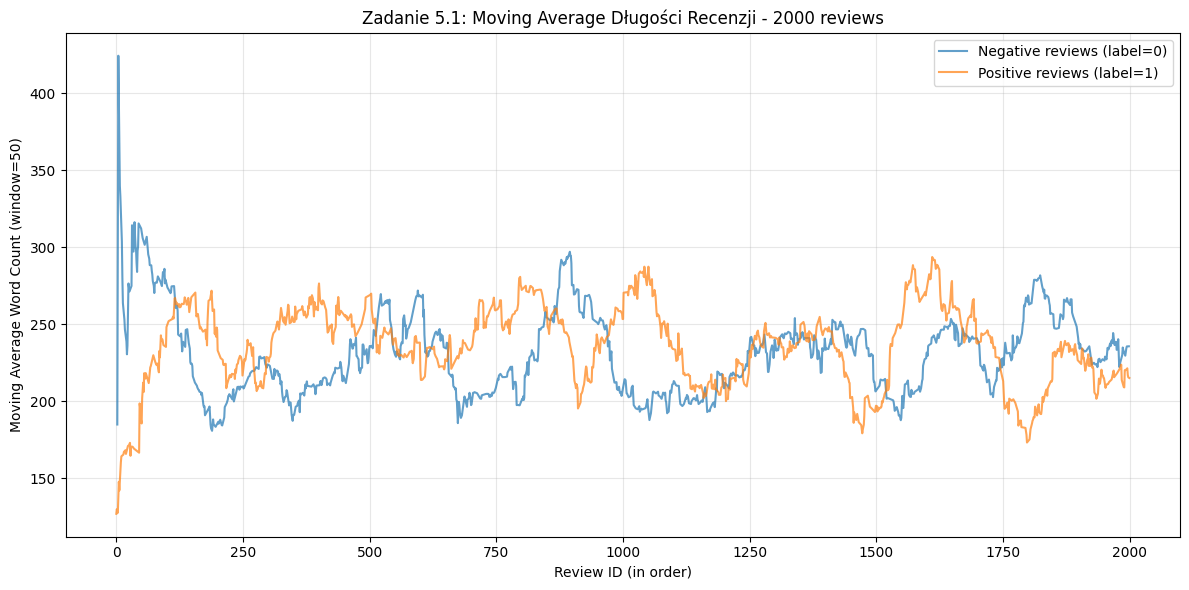

In [43]:
# Zadanie 5.1: window functions (implementation)
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

print("="*70)
print("ZADANIE 5.1: Window functions - ranking i analityka zaawansowana")
print("="*70)

# Przygotuj DataFrame z word_count (z poprzedniego przykładu)
# (reuse df_words z poprzedniej komórki)

# 1. Ranking recenzji w klasie po długości (longest = rank 1)
print("\n1. RANKING W KLASIE PO DLUGOSCI")
print("-"*70)
w_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df_ranked = df_words.withColumn("rank_in_class", F.row_number().over(w_rank))
df_ranked.select("id", "label", "word_count", "rank_in_class").where("rank_in_class <= 5").show(10)

# 2. Top 3 najdłuższe recenzje per klasa
print("\n2. TOP 3 NAJDLUZSZE RECENZJE PER KLASA")
print("-"*70)
df_top3 = df_ranked.where("rank_in_class <= 3").select("id", "label", "word_count", "rank_in_class")
df_top3.orderBy("label", "rank_in_class").show()

# 3. Różnica od średniej długości w klasie
print("\n3. ROZNICA OD SREDNIEJ DLUGOSCI W KLASIE")
print("-"*70)
w_avg = Window.partitionBy("label")
df_diff = df_words.withColumn("avg_words_in_class", F.avg("word_count").over(w_avg)) \
                   .withColumn("diff_from_avg", F.col("word_count") - F.col("avg_words_in_class"))
df_diff.select("id", "label", "word_count", "avg_words_in_class", 
               F.round("diff_from_avg", 1).alias("diff")).where("id < 10").show()

# 4. Moving average długości w oknie 50 ostatnich recenzji (per klasa)
print("\n4. MOVING AVERAGE - OKNO 50 OSTATNICH RECENZJI")
print("-"*70)
w_moving = Window.partitionBy("label").orderBy("id").rowsBetween(-49, 0)
df_moving = df_words.withColumn("moving_avg_50", 
                                F.avg("word_count").over(w_moving)) \
                     .select("id", "label", "word_count", F.round("moving_avg_50", 1).alias("moving_avg"))
df_moving.show(10)

# 5. Wizualizacja moving average
print("\n5. WIZUALIZACJA MOVING AVERAGE")
print("-"*70)

# Zbierz dane do visualizacji (collect do Pythona)
data_class_0 = df_moving.where("label == 0").collect()
data_class_1 = df_moving.where("label == 1").collect()

ids_0 = [row["id"] for row in data_class_0]
moving_0 = [row["moving_avg"] for row in data_class_0]

ids_1 = [row["id"] for row in data_class_1]
moving_1 = [row["moving_avg"] for row in data_class_1]

# Matplotlib - 2 linie (jedna na klasę)
plt.figure(figsize=(12, 6))
plt.plot(ids_0, moving_0, label="Negative reviews (label=0)", alpha=0.7, linewidth=1.5)
plt.plot(ids_1, moving_1, label="Positive reviews (label=1)", alpha=0.7, linewidth=1.5)
plt.xlabel("Review ID (in order)")
plt.ylabel("Moving Average Word Count (window=50)")
plt.title("Zadanie 5.1: Moving Average Długości Recenzji - 2000 reviews")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(WORKDIR / "task5_1_moving_average.png", dpi=100)
print("Wykres zapisany: task5_1_moving_average.png")
plt.show()


---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [44]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

  [timer] get_imdb_subset -> 0.00s
=== KOMPLETNOSC ===
Nulle: {'text': np.int64(0), 'label': np.int64(0), 'word_count': np.int64(0), 'char_count': np.int64(0)}

=== UNIKALNOSC ===
Duplikaty tekstu: 0

=== ROZKLAD LABELI ===
label
1    0.5
0    0.5
Name: frac, dtype: float64
Stosunek mniejszosci do wiekszosci: 1.000 (1.0 = idealnie zbalansowane)

=== ANOMALIE DLUGOSCI ===
P1: 42, P99: 889, outlierow (poza P1-P99): 39

=== ANOMALIE TRESCI ===
Tekst zawiera HTML tagi: 1189 (59.5%)
Bardzo krotkie recenzje (<5 slow): 0

INSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!


## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [48]:
# Zadanie 6.1: DataContract + DataValidator (implementation)
from datetime import datetime
from dataclasses import dataclass, field
from typing import Callable
import pandas as pd
import numpy as np

@dataclass
class Rule:
    name: str
    check: Callable
    severity: str = "warning"  # info | warning | error

class DataContract:
    def __init__(self, name: str):
        self.name = name
        self.rules: list[Rule] = []
    
    def add_rule(self, name: str, check: Callable, severity: str = "warning"):
        """Dodaj regułę do kontraktu."""
        self.rules.append(Rule(name=name, check=check, severity=severity))
        return self

class DataValidator:
    def __init__(self, contract: DataContract):
        self.contract = contract
        self.report = {}
    
    def validate(self, df) -> dict:
        """Iteruj po regułach, zwróć raport, raise jeśli severity=error i rule failed."""
        self.report = {
            "timestamp": datetime.now().isoformat(),
            "contract": self.contract.name,
            "rules": {},
            "summary": {"passed": 0, "warnings": 0, "errors": 0}
        }
        
        for rule in self.contract.rules:
            try:
                result = rule.check(df)
                if isinstance(result, (bool, int, np.bool_)):
                    passed = bool(result)
                    details = ""
                else:
                    # Convert numpy bool to Python bool
                    passed = bool(result[0])
                    details = str(result[1])
            except Exception as e:
                passed = False
                details = str(e)
            
            self.report["rules"][rule.name] = {
                "passed": bool(passed),  # Ensure Python bool, not numpy bool
                "severity": rule.severity,
                "details": str(details)
            }
            
            # Zlicz statystyki
            if passed:
                self.report["summary"]["passed"] += 1
            elif rule.severity == "warning":
                self.report["summary"]["warnings"] += 1
            elif rule.severity == "error":
                self.report["summary"]["errors"] += 1
                raise ValueError(f"Data quality error: rule '{rule.name}' failed - {details}")
        
        return self.report

# Przygotuj dane
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()

# === Zbuduj kontrakt dla imdb z minimum 6 regułami ===
contract = DataContract("IMDB Data Quality")

# Reguła 1: no_nulls
def check_no_nulls(df):
    nulls = int(df[["text", "label"]].isnull().sum().sum())
    return (nulls == 0, f"NULL count: {nulls}")
contract.add_rule("no_nulls", check_no_nulls, severity="error")

# Reguła 2: labels_in_set
def check_labels_in_set(df):
    valid = set(df["label"].unique()).issubset({0, 1})
    invalid = set(df["label"].unique()) - {0, 1}
    return (valid, f"Invalid labels: {invalid if invalid else 'none'}")
contract.add_rule("labels_in_set", check_labels_in_set, severity="error")

# Reguła 3: min_word_count
def check_min_word_count(df):
    min_wc = 5
    fails = int((df["word_count"] < min_wc).sum())
    return (fails == 0, f"Reviews with < {min_wc} words: {fails}")
contract.add_rule("min_word_count", check_min_word_count, severity="error")

# Reguła 4: max_word_count (sanity)
def check_max_word_count(df):
    max_wc = 2000
    fails = int((df["word_count"] > max_wc).sum())
    return (fails == 0, f"Reviews with > {max_wc} words: {fails}")
contract.add_rule("max_word_count", check_max_word_count, severity="error")

# Reguła 5: no_duplicates
def check_no_duplicates(df):
    dups = int(df["text"].duplicated().sum())
    return (dups == 0, f"Duplicate texts: {dups}")
contract.add_rule("no_duplicates", check_no_duplicates, severity="error")

# Reguła 6: class_balance (stosunek między 0.5 a 1.5)
def check_class_balance(df):
    counts = df["label"].value_counts()
    if len(counts) < 2:
        return (False, "Not all classes present")
    ratio = float(counts.min() / counts.max())
    balanced = 0.5 <= ratio <= 1.5
    return (balanced, f"Class ratio min/max: {ratio:.3f}")
contract.add_rule("class_balance", check_class_balance, severity="error")

# Bonus reguła: no_html_tags (warning, nie error)
def check_no_html_tags(df):
    has_html = int(df["text"].str.contains(r"<[^>]+>", regex=True, na=False).sum())
    return (has_html == 0, f"Reviews with HTML tags: {has_html} ({has_html/len(df)*100:.1f}%)")
contract.add_rule("no_html_tags", check_no_html_tags, severity="warning")

# === Uruchom walidację ===
print("="*70)
print("ZADANIE 6.1: Data Quality Framework")
print("="*70)

validator = DataValidator(contract)
try:
    report = validator.validate(df_pd)
    print("\nWalidacja powiodła się (wszystkie 'error' rules przeszły)")
except ValueError as e:
    print(f"\nWalidacja nie powiodła się: {e}")
    report = validator.report

# Wydrukuj raport
print("\n" + "-"*70)
print("RAPORT WALIDACJI")
print("-"*70)
print(f"Timestamp: {report['timestamp']}")
print(f"Summary: {report['summary']['passed']} passed, {report['summary']['warnings']} warnings, {report['summary']['errors']} errors")
print("\nSzczegóły reguł:")
for rule_name, details in report["rules"].items():
    status = "OK" if details["passed"] else "ERROR" if details["severity"] == "error" else "WARN"
    severity_tag = f"[{details['severity'].upper()}]"
    print(f"  {status} {rule_name:25} {severity_tag:10} {details['details']}")

# === Zapisz raport do JSON ===
report_path = WORKDIR / "data_quality_report.json"
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print(f"\nRaport zapisany: {report_path}")

  [timer] get_imdb_subset -> 0.00s
ZADANIE 6.1: Data Quality Framework

Walidacja powiodła się (wszystkie 'error' rules przeszły)

----------------------------------------------------------------------
RAPORT WALIDACJI
----------------------------------------------------------------------
Timestamp: 2026-06-17T22:17:39.879886
Summary: 6 passed, 1 warnings, 0 errors

Szczegóły reguł:
  OK no_nulls                  [ERROR]    NULL count: 0
  OK labels_in_set             [ERROR]    Invalid labels: none
  OK min_word_count            [ERROR]    Reviews with < 5 words: 0
  OK max_word_count            [ERROR]    Reviews with > 2000 words: 0
  OK no_duplicates             [ERROR]    Duplicate texts: 0
  OK class_balance             [ERROR]    Class ratio min/max: 1.000
  WARN no_html_tags              [WARNING]  Reviews with HTML tags: 1189 (59.5%)

Raport zapisany: _workspace\data_quality_report.json


---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [ ]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")